In [ ]:
import zipfile
import os

zip_path = '/content/archive(1).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/netflix_data')

print("ZIP file extracted successfully!")
print(os.listdir('/content/netflix_data'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/archive(1).zip'

In [ ]:
import os

os.listdir('/content')

['.config', 'archive.zip', 'sample_data']

In [ ]:
import zipfile

zip_path = '/content/archive.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/netflix_data')

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [ ]:
import os

os.listdir('/content/netflix_data')

['netflix_titles.csv']

In [ ]:
zip_path = '/content/archive.zip'

In [ ]:
import os
os.listdir('/content')

['.config', 'archive.zip', 'netflix_data', 'sample_data']

In [ ]:
import zipfile

zip_path = '/content/archive.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/netflix_data')

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [ ]:
import os

print(os.listdir('/content/netflix_data'))

['netflix_titles.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/netflix_data/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


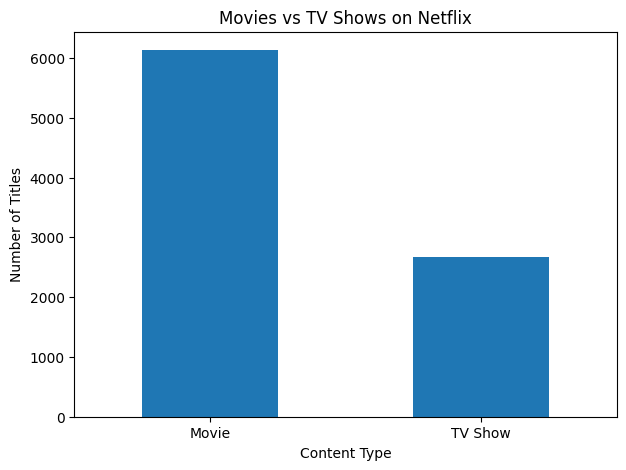

In [ ]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 5))
type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.show()

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
content_by_year = df['date_added'].dt.year.value_counts().sort_index()

content_by_year.head()

,count
date_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3


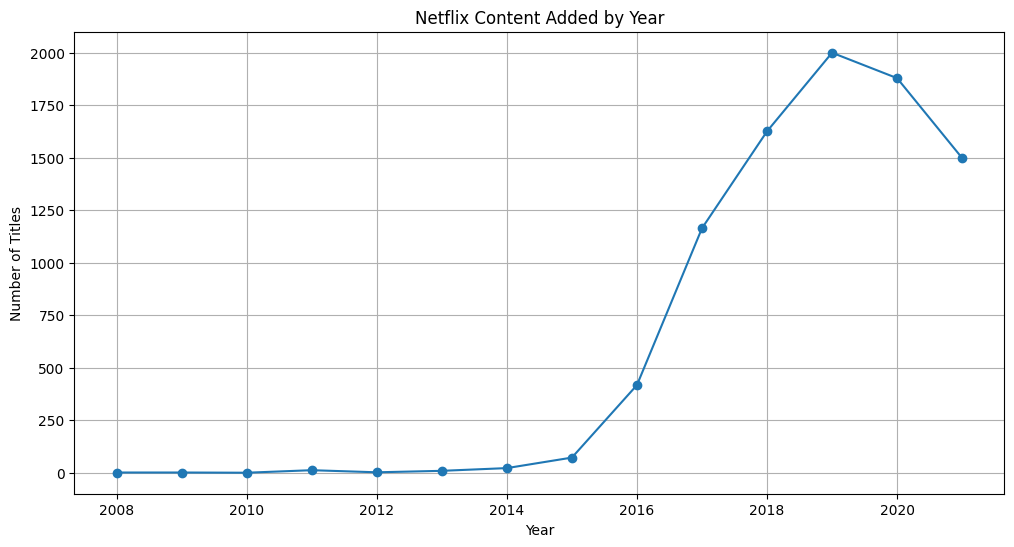

In [ ]:
plt.figure(figsize=(12, 6))

content_by_year.plot(kind='line', marker='o')

plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

In [ ]:
genres = df['listed_in'].dropna().str.split(', ').explode()

genres.head()

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows


In [ ]:
genre_counts = genres.value_counts()

genre_counts.head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


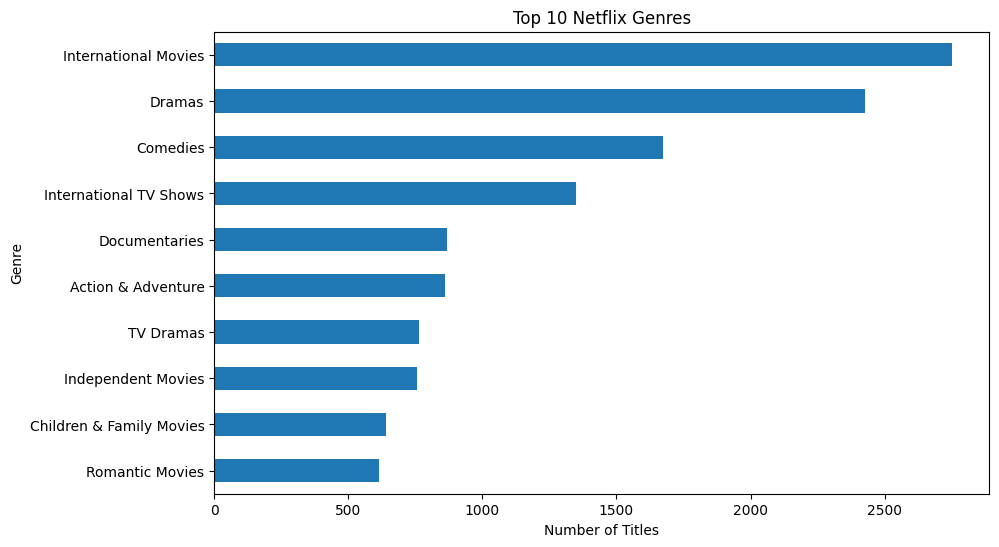

In [ ]:
plt.figure(figsize=(10, 6))

genre_counts.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

In [ ]:
countries = df['country'].dropna().str.split(', ').explode()

In [ ]:
country_counts = countries.value_counts()

country_counts.head(10)

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


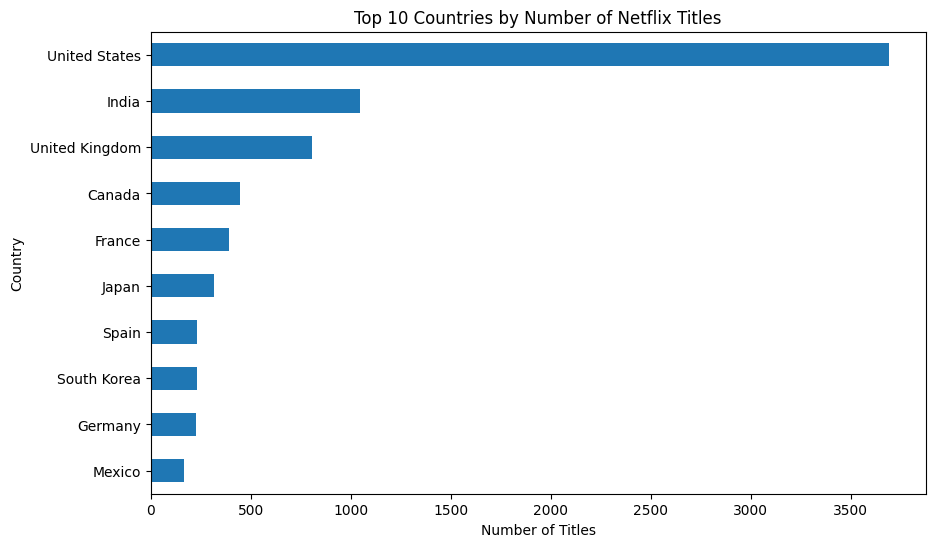

In [ ]:
plt.figure(figsize=(10, 6))

country_counts.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

In [ ]:
rating_counts = df['rating'].value_counts()

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


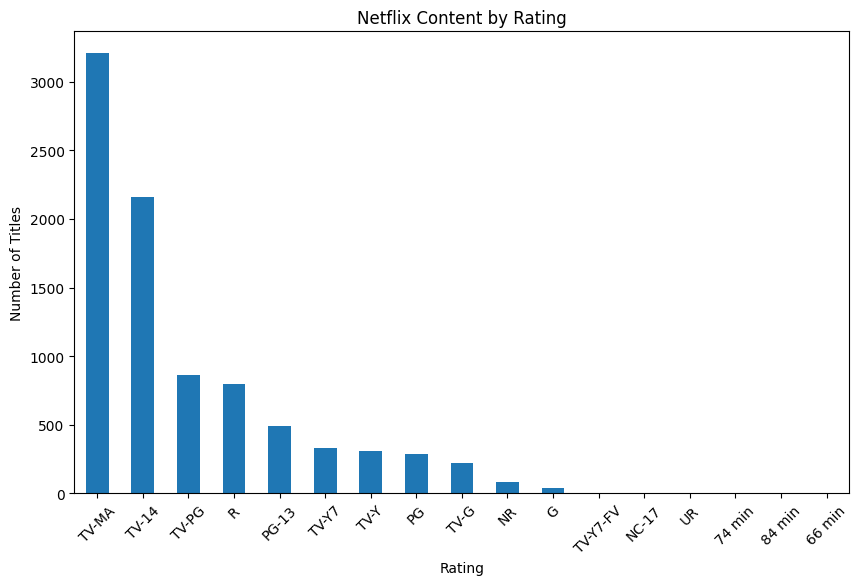

In [ ]:
plt.figure(figsize=(10, 6))

rating_counts.plot(kind='bar')

plt.title('Netflix Content by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

In [ ]:
movies = df[df['type'] == 'Movie'].copy()

In [ ]:
movies['duration_minutes'] = (
    movies['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)|

SyntaxError: invalid syntax (1990946191.py, line 5)

In [ ]:
movies['duration_minutes'] = (
    movies['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

In [ ]:
movies['duration_minutes'].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


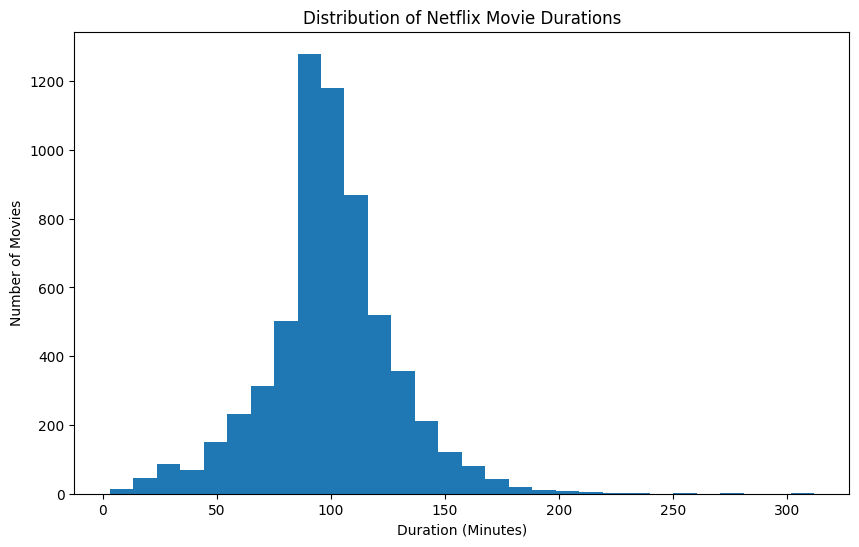

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    movies['duration_minutes'].dropna(),
    bins=30
)

plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

In [ ]:
type_counts = df['type'].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
print(genre_counts.head(5))

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


In [ ]:
print(country_counts.head(5))

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64


In [ ]:
print(rating_counts.head(5))

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


In [ ]:
print("Average movie duration:", movies['duration_minutes'].mean())

Average movie duration: 99.57718668407311


In [ ]:
movie_genres = (
    df[df['type'] == 'Movie']['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(movie_genres.head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64


In [ ]:
top_movie_genres = movie_genres.head(5)

top_tv_genres = tv_genres.head(5)

comparison = pd.DataFrame({
    'Movies': top_movie_genres,
    'TV Shows': top_tv_genres
}).fillna(0)

comparison.plot(kind='bar', figsize=(10, 6))

plt.title('Top Genres: Movies vs TV Shows')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

NameError: name 'tv_genres' is not defined

In [ ]:
tv_genres = (
    df[df['type'] == 'TV Show']['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(tv_genres.head(10))

listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: count, dtype: int64


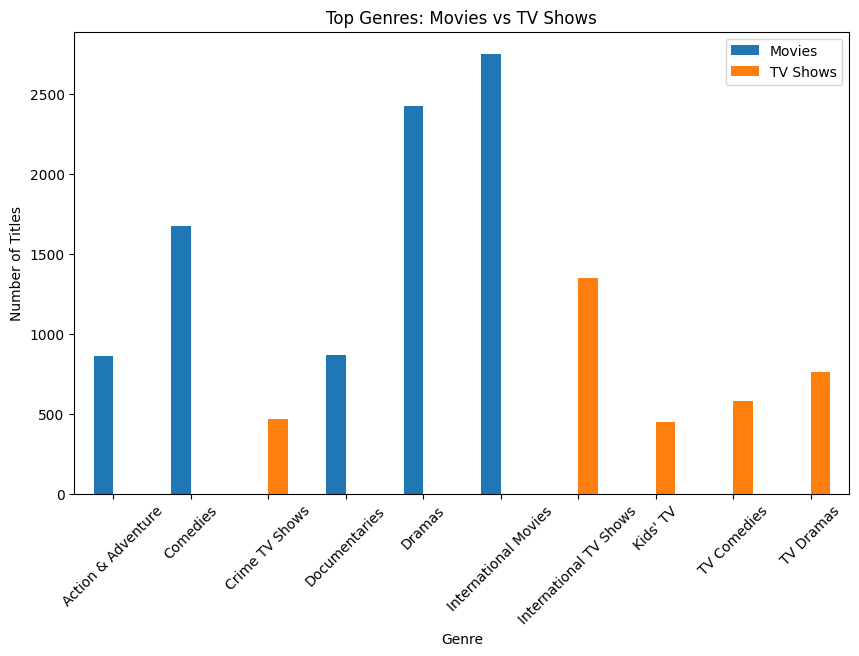

In [ ]:
top_movie_genres = movie_genres.head(5)

top_tv_genres = tv_genres.head(5)

comparison = pd.DataFrame({
    'Movies': top_movie_genres,
    'TV Shows': top_tv_genres
}).fillna(0)

comparison.plot(kind='bar', figsize=(10, 6))

plt.title('Top Genres: Movies vs TV Shows')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

In [ ]:
sql_df = df.copy()

print(sql_df.shape)

(8807, 12)


In [ ]:
sql_df = sql_df[
    [
        'show_id',
        'type',
        'title',
        'country',
        'release_year',
        'rating',
        'duration',
        'listed_in'
    ]
]

sql_df.head()

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [ ]:
sql_df.to_csv('/content/netflix_sql_data.csv', index=False)

print("SQL-ready dataset created successfully!")

SQL-ready dataset created successfully!


In [ ]:
sql_queries = """

-- 1. Total number of titles
SELECT COUNT(*) AS total_titles
FROM netflix_titles;


-- 2. Movies vs TV Shows
SELECT type, COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY type
ORDER BY total_titles DESC;


-- 3. Number of titles by release year
SELECT release_year, COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY release_year
ORDER BY release_year;


-- 4. Top countries
SELECT country, COUNT(*) AS total_titles
FROM netflix_titles
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;


-- 5. Content by rating
SELECT rating, COUNT(*) AS total_titles
FROM netflix_titles
WHERE rating IS NOT NULL
GROUP BY rating
ORDER BY total_titles DESC;


-- 6. Content by genre
SELECT listed_in, COUNT(*) AS total_titles
FROM netflix_titles
WHERE listed_in IS NOT NULL
GROUP BY listed_in
ORDER BY total_titles DESC
LIMIT 10;

"""

print(sql_queries)



-- 1. Total number of titles
SELECT COUNT(*) AS total_titles
FROM netflix_titles;


-- 2. Movies vs TV Shows
SELECT type, COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY type
ORDER BY total_titles DESC;


-- 3. Number of titles by release year
SELECT release_year, COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY release_year
ORDER BY release_year;


-- 4. Top countries
SELECT country, COUNT(*) AS total_titles
FROM netflix_titles
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;


-- 5. Content by rating
SELECT rating, COUNT(*) AS total_titles
FROM netflix_titles
WHERE rating IS NOT NULL
GROUP BY rating
ORDER BY total_titles DESC;


-- 6. Content by genre
SELECT listed_in, COUNT(*) AS total_titles
FROM netflix_titles
WHERE listed_in IS NOT NULL
GROUP BY listed_in
ORDER BY total_titles DESC
LIMIT 10;




In [ ]:
from google.colab import files

files.download('/content/netflix_sql_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Load the SQL-ready CSV
sql_df = pd.read_csv('/content/netflix_sql_data.csv')

# Replace missing values with None
sql_df = sql_df.where(pd.notnull(sql_df), None)

# Create SQL INSERT statements
with open('/content/netflix_insert.sql', 'w', encoding='utf-8') as f:
    f.write("USE ott_content_analysis;\n\n")

    for _, row in sql_df.iterrows():
        values = []

        for value in row:
            if value is None:
                values.append("NULL")
            else:
                value = str(value).replace("\\", "\\\\").replace("'", "''")
                values.append(f"'{value}'")

        f.write(
            "INSERT INTO netflix_titles "
            "(show_id, type, title, country, release_year, rating, duration, listed_in) "
            f"VALUES ({', '.join(values)});\n"
        )

print("SQL file created successfully!")
print("Number of records:", len(sql_df))

SQL file created successfully!
Number of records: 8807


In [ ]:
from google.colab import files

files.download('/content/netflix_insert.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>